In [ ]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from PIL import Image
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader

# ---- config ----
SEED = 7
BATCH_SIZE = 256
TRAIN_STEPS = 450
RANDOM_STEPS = 1200
EVAL_BATCH_SIZE = 512
STEP_LR = 0.10
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [ ]:
# ---- model ----
class SmallCifarCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 15, 3, padding=1)
        self.conv2 = nn.Conv2d(15, 30, 3, padding=1)
        self.conv3 = nn.Conv2d(30, 60, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(60 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


# ---- data ----
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
trainset = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=transform)
loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                    generator=torch.Generator().manual_seed(SEED))

In [ ]:
# ---- train ----
model = SmallCifarCNN().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.06, momentum=0.9, weight_decay=5e-4)

model.train()
step = 0; t0 = time.time()
while step < TRAIN_STEPS:
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        loss = F.cross_entropy(model(xb), yb)
        loss.backward(); opt.step()
        step += 1
        if step == 1 or step % 100 == 0 or step == TRAIN_STEPS:
            print(f"step {step:4d}/{TRAIN_STEPS}  loss={loss.item():.4f}")
        if step >= TRAIN_STEPS: break
print(f"trained in {time.time()-t0:.1f}s")

step    1/450  loss=2.3031
step  100/450  loss=1.5455
step  200/450  loss=1.1918
step  300/450  loss=1.0052
step  400/450  loss=1.0866
step  450/450  loss=0.9686
trained in 28.3s


In [ ]:
# ---- gradient step vs random steps at equal radius ----
eval_xb = torch.stack([trainset[i][0] for i in range(EVAL_BATCH_SIZE)]).to(device)
eval_yb = torch.tensor([trainset[i][1] for i in range(EVAL_BATCH_SIZE)]).to(device)

model.eval()
params = [p for p in model.parameters() if p.requires_grad]
model.zero_grad(set_to_none=True)
base_loss = F.cross_entropy(model(eval_xb), eval_yb)
base_loss.backward()

theta0 = parameters_to_vector(params).detach().clone()
grad = torch.cat([p.grad.detach().reshape(-1) for p in params])
step_radius = (STEP_LR * grad.norm()).item()

@torch.no_grad()
def loss_at(theta):
    vector_to_parameters(theta, params)
    out = F.cross_entropy(model(eval_xb), eval_yb).item()
    vector_to_parameters(theta0, params)
    return out

gradient_loss = loss_at(theta0 - STEP_LR * grad)

gen = torch.Generator(device=theta0.device).manual_seed(SEED + 999)
random_losses = np.empty(RANDOM_STEPS)
for i in range(RANDOM_STEPS):
    d = torch.randn(theta0.numel(), generator=gen, device=theta0.device, dtype=theta0.dtype)
    d /= d.norm().clamp_min(1e-12)
    random_losses[i] = loss_at(theta0 + step_radius * d)
    if (i + 1) % 250 == 0: print(f"random {i+1}/{RANDOM_STEPS}")

sigma = (random_losses.mean() - gradient_loss) / random_losses.std(ddof=1)
print(f"base={base_loss.item():.4f}  grad={gradient_loss:.4f}  "
      f"rand_mean={random_losses.mean():.4f}  sigma={sigma:.2f}")

random 250/1200
random 500/1200
random 750/1200
random 1000/1200
base=0.8506  grad=0.7869  rand_mean=0.8507  sigma=155.85


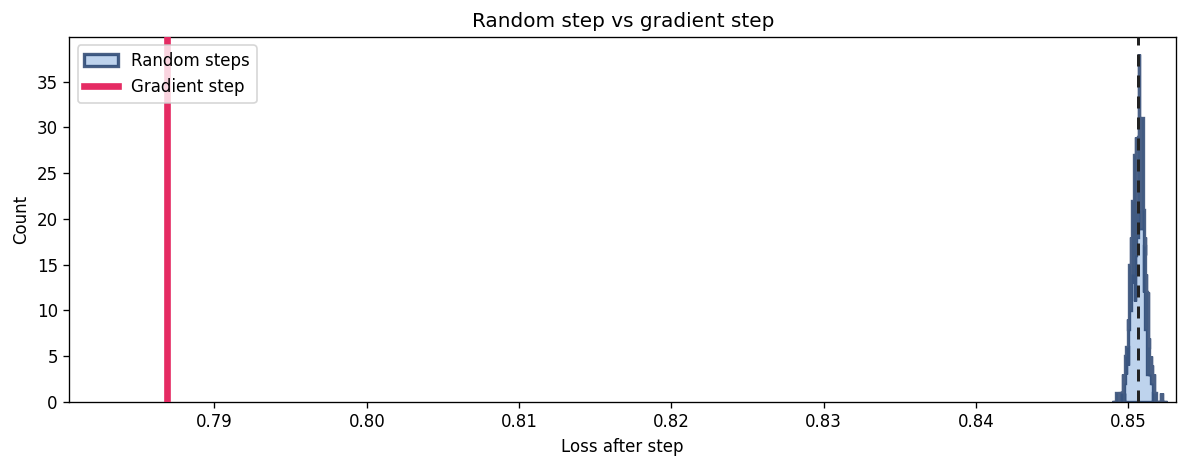

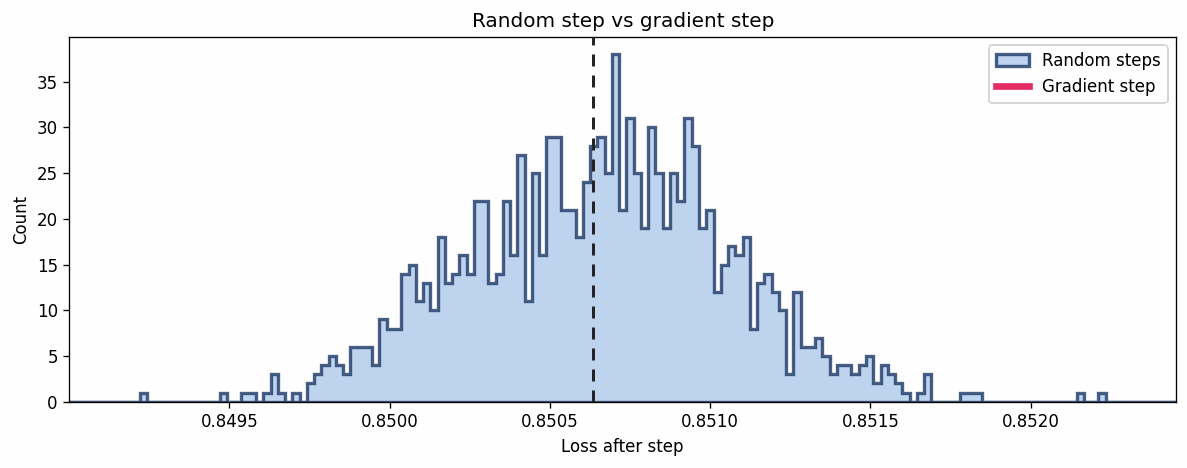

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image

OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)


def plot_hist_zoom(base, grad_loss, rand, radius, xlim, rand_center, out_path=None):
    fig, ax = plt.subplots(figsize=(10.0, 4.0), dpi=120)

    rand_lo, rand_hi = rand.min(), rand.max()
    pad = 0.1 * (rand_hi - rand_lo + 1e-9)
    bin_edges = np.linspace(rand_lo - pad, rand_hi + pad, 160)

    ax.hist(
        rand,
        bins=bin_edges,
        histtype="stepfilled",
        color="#a8c5e8",
        alpha=0.75,
        edgecolor="#0d2b5c",
        linewidth=2.0,
        label="Random steps",
    )
    ax.axvline(grad_loss, color="#e52b63", linewidth=4, label="Gradient step", zorder=5)
    ax.axvline(base, color="#222", linewidth=1.8, linestyle=(0, (4, 3)), zorder=4)

    ax.set_xlim(*xlim)
    ax.set_ylim(0, None)
    ax.set_title("Random step vs gradient step")
    ax.set_xlabel("Loss after step")
    ax.set_ylabel("Count")

    span = xlim[1] - xlim[0]
    grad_frac = (grad_loss - xlim[0]) / span
    rand_frac = (rand_center - xlim[0]) / span
    left_score = min(grad_frac, rand_frac)
    right_score = 1.0 - max(grad_frac, rand_frac)
    ax.legend(loc="upper left" if left_score >= right_score else "upper right")

    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, bbox_inches="tight", facecolor="white")
    return fig


rand_lo, rand_hi = float(random_losses.min()), float(random_losses.max())
rand_center = 0.5 * (rand_lo + rand_hi)
rand_half = 0.5 * (rand_hi - rand_lo)

x_left_start  = rand_center - 1.15 * rand_half
x_right_start = rand_center + 1.15 * rand_half


margin = 0.10 * abs(gradient_loss - rand_center)
x_left_end  = gradient_loss - margin
x_right_end = rand_center + 1.6 * rand_half

png_path = OUT_DIR / "random_step_vs_gradient_step.png"
plot_hist_zoom(
    base_loss.item(), gradient_loss, random_losses, step_radius,
    xlim=(x_left_end, x_right_end), rand_center=rand_center, out_path=png_path,
)
plt.show()


N_FRAMES = 60
alphas = np.linspace(0.0, 1.0, N_FRAMES)
right_edges = x_right_start + alphas * (x_right_end - x_right_start)
dist_start = x_right_start - x_left_start
dist_end   = x_right_end   - x_left_end
dists = np.exp(np.log(dist_start) + alphas * (np.log(dist_end) - np.log(dist_start)))
left_edges = right_edges - dists

frame_dir = OUT_DIR / "gif_frames_zoom"; frame_dir.mkdir(exist_ok=True)
frames = []
for k, (xl, xr) in enumerate(zip(left_edges, right_edges)):
    fp = frame_dir / f"frame_{k:03d}.png"
    plot_hist_zoom(base_loss.item(), gradient_loss, random_losses, step_radius,
                   (xl, xr), rand_center, out_path=fp)
    plt.close()
    frames.append(Image.open(fp).convert("P", palette=Image.Palette.ADAPTIVE))

durations = [80] * (len(frames) - 1) + [1500]

gif_path = OUT_DIR / "random_step_vs_gradient_step.gif"
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=durations,
    loop=0,
)

np.savez(
    OUT_DIR / "losses.npz",
    base_loss=base_loss.item(), gradient_loss=gradient_loss,
    random_losses=random_losses, sigma=sigma, step_radius=step_radius, lr=STEP_LR,
)

from IPython.display import Image as DisplayImage, display
display(DisplayImage(filename=str(gif_path)))


## RandOpt

start view (np.float64(0.6632500000000001), np.float64(0.7297)) (no red line)  ->  end (0.65, 0.78) (red line in view)
rendering 50 frames...
  10/50
  20/50
  30/50
  40/50
  50/50
saved GIF -> outputs/random_step_vs_gradient_step_acc.gif


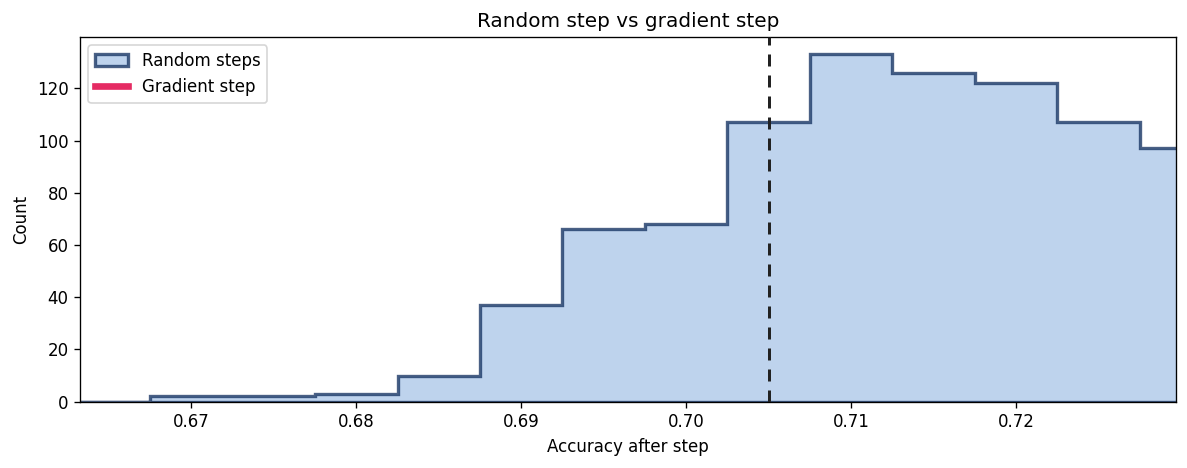

In [ ]:
# ---- view ranges ----
rand_center = 0.5 * (rand.min() + rand.max())
rand_half   = 0.5 * (rand.max() - rand.min())

# Final view: user-requested tight window.
x1 = (0.65, 0.78)
assert x1[0] < grad_acc < x1[1], f"final view must contain grad_acc={grad_acc}"

# Starting view: tight on rand distribution, EXCLUDING grad_acc.
# Mirrors the loss gif (rand_center ± 1.15 * rand_half) so the red line
# enters the frame partway through the zoom instead of being visible from frame 0.
PAD = 1.15
x0 = (rand_center - PAD * rand_half, rand_center + PAD * rand_half)
# safety: if grad_acc happens to fall inside, pull the facing edge in slightly
if x0[0] <= grad_acc <= x0[1]:
    if grad_acc > rand_center:
        x0 = (x0[0], min(x0[1], grad_acc - 0.02 * max(grad_acc - rand_center, 1e-4)))
    else:
        x0 = (max(x0[0], grad_acc + 0.02 * max(rand_center - grad_acc, 1e-4)), x0[1])

print(f"start view {x0} (no red line)  ->  end {x1} (red line in view)")

N_FRAMES, ANCHOR = 50, 0.45
alphas = np.linspace(0, 1, N_FRAMES)

def interp_log(d_start, d_anchor, d_end, alphas, anchor):
    """Two-segment log interpolation: start -> anchor at `anchor`, then anchor -> end."""
    a = np.where(alphas <= anchor, alphas / anchor, (alphas - anchor) / (1 - anchor))
    pre  = np.exp(np.log(d_start)  + a * (np.log(d_anchor) - np.log(d_start)))
    post = np.exp(np.log(d_anchor) + a * (np.log(d_end)    - np.log(d_anchor)))
    return np.where(alphas <= anchor, pre, post)

# edge distances from rand_center
dL_start, dL_end = rand_center - x0[0], rand_center - x1[0]
dR_start, dR_end = x0[1] - rand_center, x1[1] - rand_center

# Anchor the edge that faces grad_acc: at frame ANCHOR, that edge equals grad_acc,
# which is the exact moment the red line appears at the screen edge.
if grad_acc > rand_center:
    dR_anchor_raw = grad_acc - rand_center
    r_lo, r_hi = sorted([dR_start, dR_end])
    dR_anchor = float(np.clip(dR_anchor_raw, r_lo * 1.001, r_hi * 0.999))
    dL_anchor = float(np.exp(np.log(dL_start) + ANCHOR * (np.log(dL_end) - np.log(dL_start))))
else:
    dL_anchor_raw = rand_center - grad_acc
    l_lo, l_hi = sorted([dL_start, dL_end])
    dL_anchor = float(np.clip(dL_anchor_raw, l_lo * 1.001, l_hi * 0.999))
    dR_anchor = float(np.exp(np.log(dR_start) + ANCHOR * (np.log(dR_end) - np.log(dR_start))))

dR = interp_log(dR_start, dR_anchor, dR_end, alphas, ANCHOR)
dL = interp_log(dL_start, dL_anchor, dL_end, alphas, ANCHOR)
left_edges  = np.clip(rand_center - dL, 0, 1)
right_edges = np.clip(rand_center + dR, 0, 1)

# ---- render frames ----
print(f"rendering {N_FRAMES} frames...")
frames = []
for k, (xl, xr) in enumerate(zip(left_edges, right_edges)):
    img = fig_to_pil(plot_frame((xl, xr), rand_center))
    frames.append(img.quantize(colors=256, method=Image.Quantize.MEDIANCUT))
    if (k + 1) % 10 == 0:
        print(f"  {k + 1}/{N_FRAMES}")

gif = OUT_DIR / "random_step_vs_gradient_step_acc.gif"
frames[0].save(gif, save_all=True, append_images=frames[1:],
               duration=[80] * (len(frames) - 1) + [1800], loop=0)
print(f"saved GIF -> {gif}")

from IPython.display import Image as DisplayImage, display
display(DisplayImage(filename=str(gif)))

using font: /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans-Bold.ttf @ 24px
saved -> outputs/random_step_combined_1778726206.gif



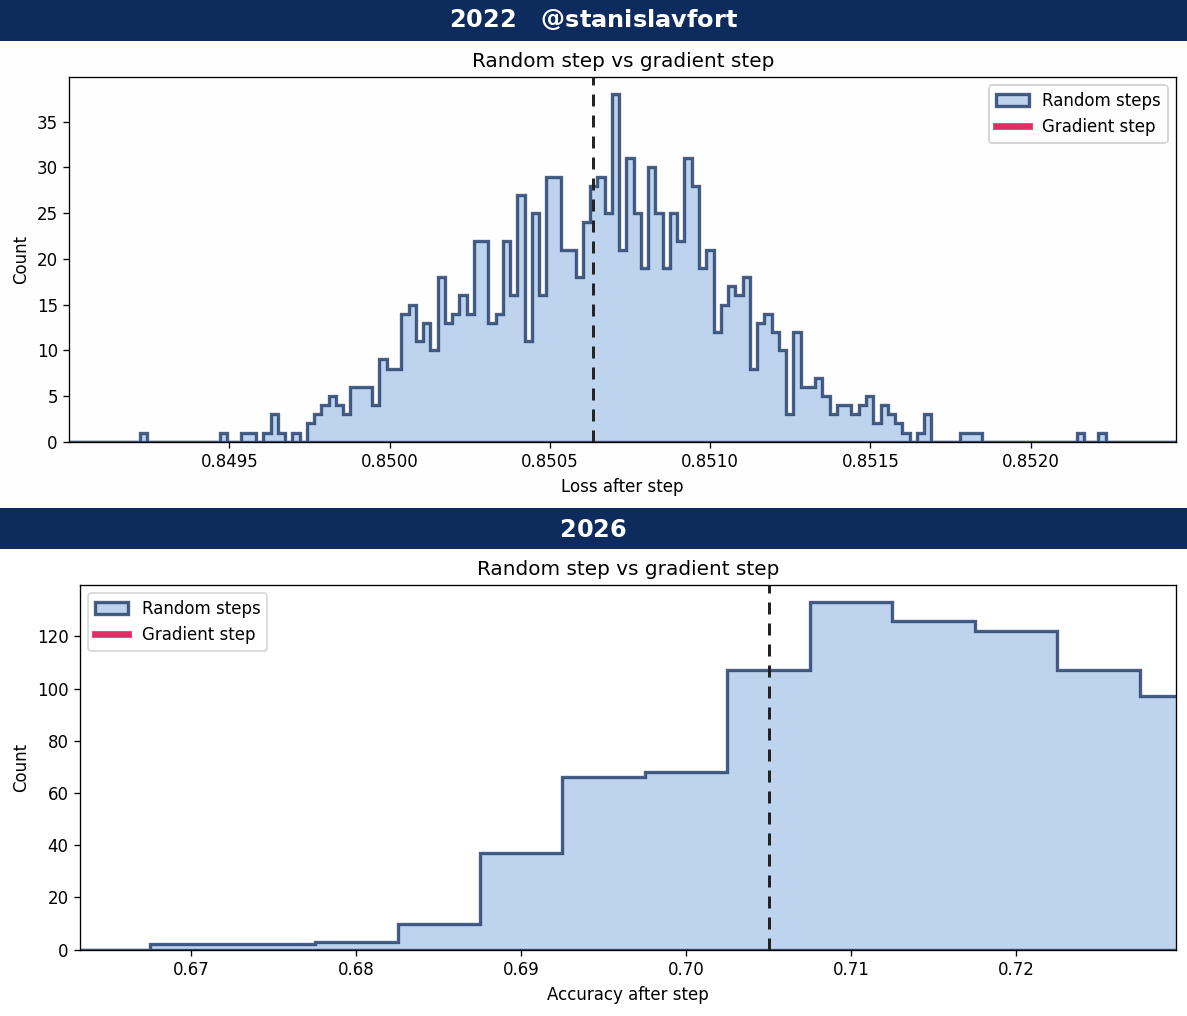

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import matplotlib, time, base64
from IPython.display import HTML, display

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
gif_top    = OUT_DIR / "random_step_vs_gradient_step.gif"
gif_bottom = OUT_DIR / "random_step_vs_gradient_step_acc.gif"
out_path   = OUT_DIR / f"random_step_combined_{int(time.time())}.gif"

LABEL_TOP    = "2022   @stanislavfort"
LABEL_BOTTOM = "2026"
BANNER_H  = 40
FONT_SIZE = 24

FONT_PATH = str(Path(matplotlib.__file__).parent / "mpl-data" / "fonts" / "ttf" / "DejaVuSans-Bold.ttf")
assert Path(FONT_PATH).exists(), f"font still not found at {FONT_PATH}"
font = ImageFont.truetype(FONT_PATH, FONT_SIZE)
print(f"using font: {FONT_PATH} @ {FONT_SIZE}px")


def load_frames(path):
    im = Image.open(path)
    out = []
    for i in range(im.n_frames):
        im.seek(i)
        out.append((im.convert("RGB"), im.info.get("duration", 80)))
    return out


def resample(frames, n):
    import numpy as np
    durs = np.array([d for _, d in frames], dtype=float)
    t_src = np.concatenate([[0.0], np.cumsum(durs)])[:-1] / durs.sum()
    t_dst = np.linspace(0, 1, n, endpoint=False)
    idx = np.searchsorted(t_src, t_dst, side="right") - 1
    return [frames[i][0] for i in idx]


top_frames = load_frames(gif_top)
bot_frames = load_frames(gif_bottom)
N = max(len(top_frames), len(bot_frames))
top_seq = resample(top_frames, N)
bot_seq = resample(bot_frames, N)

W = min(top_seq[0].width, bot_seq[0].width)
def fit_width(img):
    if img.width == W: return img
    h = round(img.height * W / img.width)
    return img.resize((W, h), Image.LANCZOS)
top_seq = [fit_width(f) for f in top_seq]
bot_seq = [fit_width(f) for f in bot_seq]


def with_banner(img, label):
    out = Image.new("RGB", (img.width, img.height + BANNER_H), "white")
    out.paste(img, (0, BANNER_H))
    draw = ImageDraw.Draw(out)
    draw.rectangle([0, 0, img.width, BANNER_H], fill="#0d2b5c")
    bbox = draw.textbbox((0, 0), label, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    draw.text(((img.width - tw) / 2, (BANNER_H - th) / 2 - bbox[1]),
              label, font=font, fill="white")
    return out


combined = []
for t, b in zip(top_seq, bot_seq):
    top = with_banner(t, LABEL_TOP)
    bot = with_banner(b, LABEL_BOTTOM)
    canvas = Image.new("RGB", (W, top.height + bot.height), "white")
    canvas.paste(top, (0, 0))
    canvas.paste(bot, (0, top.height))
    combined.append(canvas.quantize(colors=256, method=Image.Quantize.MEDIANCUT))

durations = [100] * (len(combined) - 1) + [1800]
combined[0].save(out_path, save_all=True, append_images=combined[1:],
                 duration=durations, loop=0, disposal=2)
print(f"saved -> {out_path}")

b64 = base64.b64encode(out_path.read_bytes()).decode()
display(HTML(f'<img src="data:image/gif;base64,{b64}">'))